In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

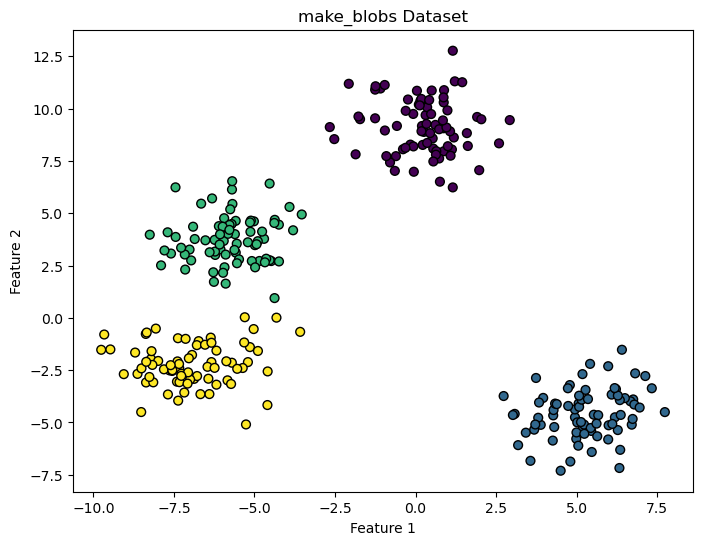

In [38]:
# Create a synthetic dataset
X, y = make_blobs(n_samples=300, centers=4, n_features=2, cluster_std=1.2, random_state=23)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", s=40, edgecolor="k")
plt.title("make_blobs Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [39]:
len(X)

300

In [40]:
epsilon = 0.7
minPts = 5

In [41]:
from scipy.spatial import cKDTree

tree = cKDTree(X)
neighbors = tree.query_ball_point(X ,r=epsilon)
neighbors

array([list([0, 33, 79, 80, 88, 213, 244]),
       list([1, 48, 55, 123, 136, 148, 180, 215, 218, 220, 258, 267, 275, 294]),
       list([2, 91, 118]),
       list([3, 5, 19, 31, 41, 114, 121, 127, 200, 202]),
       list([4, 90, 117]),
       list([3, 5, 19, 55, 114, 121, 123, 127, 180, 200, 218, 267, 275, 287, 294]),
       list([6, 35, 240]), list([7, 61, 175, 219, 237]), list([8]),
       list([9, 18]),
       list([10, 31, 45, 59, 116, 136, 137, 180, 209, 218, 243, 250, 258, 294]),
       list([11, 28, 56, 62, 81, 115, 122, 130, 171, 190, 193, 194, 278]),
       list([12, 66]), list([13, 58, 251]), list([14, 177, 280, 295]),
       list([15, 51, 68, 82, 92, 96, 104, 159, 229, 235, 265]),
       list([16, 188, 192, 220, 222, 261]), list([17, 181]),
       list([9, 18]),
       list([3, 5, 19, 55, 123, 127, 143, 200, 215, 233, 247, 252, 267, 287]),
       list([20, 47, 89, 126, 165, 248, 251, 254]),
       list([21, 26, 37, 47, 106, 126, 132, 145, 162, 224, 226, 248, 255, 257, 279, 

In [42]:
labels = np.full(len(X), None)
was_seen = np.full(len(X), False)


In [ ]:
curr_cluster = 0
for i in range(len(X)):
    if not was_seen[i]:
        was_seen[i] = True
        
        if len(neighbors[i]) < minPts:
            labels[i] = -1
        elif len(neighbors[i]) >= minPts:
            labels[i] = curr_cluster
            neighborsPts = list(neighbors[i])
            j = 0
            while j < len(neighborsPts):
                p = neighborsPts[j]
                if not was_seen[p]:
                    was_seen[p] = True
                    if not labels[p]:
                        labels[p] = curr_cluster
                    if len(neighbors[p]) >= minPts:
                        neighborsPts.extend(neighbors[p])